# 07 — ECA Attention Integration


## Section 1: Install Dependencies and Mount Drive

In [4]:
!pip install ultralytics matplotlib -q

from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

candidate_paths = [
    Path('/content/drive/MyDrive/uav-small-object-detector'),
    Path('/content/drive/MyDrive/uav-small-object-detector/UAV_small_obj_detector'),
    Path('/content/drive/MyDrive/UAV_small_obj_detector'),
]

project_root = next((path for path in candidate_paths if path.exists()), None)
if project_root is None:
    raise FileNotFoundError(
        'Could not find the project folder in Google Drive. '
        'Check MyDrive/uav-small-object-detector and MyDrive/UAV_small_obj_detector.'
    )

os.chdir(project_root)
print(f'Working directory: {project_root}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/UAV_small_obj_detector


## Section 2: Load ECA Module

In [5]:
import sys
sys.path.insert(0, '.')
from src.eca import ECA
import torch

print('ECA module loaded successfully.')

ECA module loaded successfully.


## Section 3: Load Baseline Trained Weights

In [6]:
from ultralytics import YOLO
weight_candidates = sorted(project_root.glob('runs/detect/baseline_visdrone*/weights/best.pt'))
if not weight_candidates:
    raise FileNotFoundError('Could not find baseline weights.')
model = YOLO(str(weight_candidates[-1]))
print('Baseline weights loaded.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Baseline weights loaded.


## Section 4: Inspect Model Architecture

In [7]:
for i, layer in enumerate(model.model.model):
    print(f'Layer {i}: {type(layer).__name__}')

Layer 0: Conv
Layer 1: Conv
Layer 2: C2f
Layer 3: Conv
Layer 4: C2f
Layer 5: Conv
Layer 6: C2f
Layer 7: Conv
Layer 8: C2f
Layer 9: SPPF
Layer 10: Upsample
Layer 11: Concat
Layer 12: C2f
Layer 13: Upsample
Layer 14: Concat
Layer 15: C2f
Layer 16: Conv
Layer 17: Concat
Layer 18: C2f
Layer 19: Conv
Layer 20: Concat
Layer 21: C2f
Layer 22: Detect


## Section 5: Probe Layer Output Shape

In [8]:
target_idx = 9

class ShapeProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.shape = None
    def forward(self, x):
        self.shape = x.shape
        return x

probe = ShapeProbe()
hook = model.model.model[target_idx].register_forward_hook(
    lambda m, inp, out: probe(out)
)

import torch
dummy = torch.zeros(1, 3, 640, 640)
_ = model.model(dummy)

print(f'Target layer {target_idx} output shape: {probe.shape}')
hook.remove()

Target layer 9 output shape: torch.Size([1, 256, 20, 20])


## Section 6: Restore VisDrone Dataset If Needed

In [9]:
from pathlib import Path
import os
import shutil
from PIL import Image
from ultralytics.utils.downloads import download

dataset_root = Path('/content/VisDrone')

def visdrone2yolo(root, split, source_name):
    source_dir = root / source_name
    images_dir = root / 'images' / split
    labels_dir = root / 'labels' / split
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    for img in (source_dir / 'images').glob('*.jpg'):
        shutil.move(str(img), str(images_dir / img.name))

    for ann in (source_dir / 'annotations').glob('*.txt'):
        img_path = images_dir / ann.with_suffix('.jpg').name
        img_w, img_h = Image.open(img_path).size
        dw, dh = 1.0 / img_w, 1.0 / img_h
        lines = []

        with open(ann, encoding='utf-8') as f:
            for row in [x.split(',') for x in f.read().strip().splitlines()]:
                if row[4] != '0':
                    x, y, w, h = map(int, row[:4])
                    cls = int(row[5]) - 1
                    x_center = (x + w / 2) * dw
                    y_center = (y + h / 2) * dh
                    w_norm = w * dw
                    h_norm = h * dh
                    lines.append(f'{cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n')

        with open(labels_dir / ann.name, 'w', encoding='utf-8') as out:
            out.writelines(lines)

if not (dataset_root / 'images' / 'val').exists():
    urls = [
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-dev.zip',
    ]
    download(urls, dir=dataset_root, threads=4)

    for folder, split in {
        'VisDrone2019-DET-train': 'train',
        'VisDrone2019-DET-val': 'val',
        'VisDrone2019-DET-test-dev': 'test',
    }.items():
        visdrone2yolo(dataset_root, split, folder)
        shutil.rmtree(dataset_root / folder)

print('Train images:', len(os.listdir('/content/VisDrone/images/train')))
print('Val images:', len(os.listdir('/content/VisDrone/images/val')))

Unzipping /content/VisDrone/VisDrone2019-DET-val.zip to /content/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 2.0Kfiles/s 0.5s
Unzipping /content/VisDrone/VisDrone2019-DET-test-dev.zip to /content/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 715.3files/s 4.5s
Unzipping /content/VisDrone/VisDrone2019-DET-train.zip to /content/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.3Kfiles/s 10.3s
Train images: 6471
Val images: 548


## Section 7: Attach ECA as a Forward Hook and Fine-Tune

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
in_channels = probe.shape[1]
eca = ECA(in_channels=in_channels).to(device)
print(f'ECA initialized with {in_channels} channels on {device}')

def eca_hook(module, input, output):
    return eca(output)

hook = model.model.model[target_idx].register_forward_hook(eca_hook)
print(f'ECA hook registered on layer {target_idx}')

model.train(
    data='visdrone.yaml',
    epochs=10,
    name='eca_visdrone',
    save_period=5
)
hook.remove()
print('ECA hook removed. Training complete.')

ECA initialized with 256 channels on cuda
ECA hook registered on layer 9
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/baseline_visdrone/weights/best.pt, momentum=0.937

## Section 8: Evaluate ECA-Enhanced Model

In [11]:
eca_metrics = model.val()
eca_map50 = float(eca_metrics.box.map50)
eca_map50_95 = float(eca_metrics.box.map)
print(f'ECA mAP@50:    {eca_map50:.4f}')
print(f'ECA mAP@50-95: {eca_map50_95:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1355.5±1153.3 MB/s, size: 126.7 KB)
val: Scanning /content/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 35.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.0it/s 11.9s
                   all        548      38759      0.415      0.302      0.277      0.155
            pedestrian        520       8844      0.385      0.342      0.289      0.115
                people        482       5125      0.445      0.236      0.217     0.0706
               bicycle        364       1287      0.193     0.0867     0.0471     0.0159
                   car        515      14064      0.598      0.731      0.702      0.456
                   van        421       1975   

## Section 9: Save ECA Metrics to JSON

In [12]:
import json
metrics_path = Path('results/metrics.json')
if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        all_metrics = json.load(f)
else:
    all_metrics = {}

all_metrics['eca'] = {
    'mAP50': eca_map50,
    'mAP50-95': eca_map50_95,
    'precision': float(eca_metrics.box.mp),
    'recall': float(eca_metrics.box.mr)
}

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(all_metrics, f, indent=2)

print('ECA metrics saved.')
print(json.dumps(all_metrics, indent=2))

ECA metrics saved.
{
  "baseline": {
    "mAP50": 0.29373669317784457,
    "mAP50-95": 0.1662671086264691,
    "precision": 0.39159907325051424,
    "recall": 0.30258304542539205
  },
  "cbam": {
    "mAP50": 0.30206881342972747,
    "mAP50-95": 0.17270067683582924,
    "precision": 0.414643359389183,
    "recall": 0.3024832252138724
  },
  "pseudo_label": {
    "mAP50": 0.3072394253534811,
    "mAP50-95": 0.1755445358297251,
    "precision": 0.4185700011011811,
    "recall": 0.3119329290737634,
    "accepted": 100,
    "rejected": 0,
    "acceptance_rate": 100.0,
    "weights": "/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/pseudo_label_visdrone/weights/best.pt"
  },
  "yolov11n_baseline": {
    "mAP50": 0.2651762490537308,
    "mAP50-95": 0.14755468472085892,
    "precision": 0.38817470697606105,
    "recall": 0.3011898452484491
  },
  "yolo26n_baseline": {
    "mAP50": 0.24941439738801044,
    "mAP50-95": 0.13737889200958459,
    "precision": 0.36771093891145196,
    "re

## Section 10: Generate CBAM vs ECA Comparison Chart

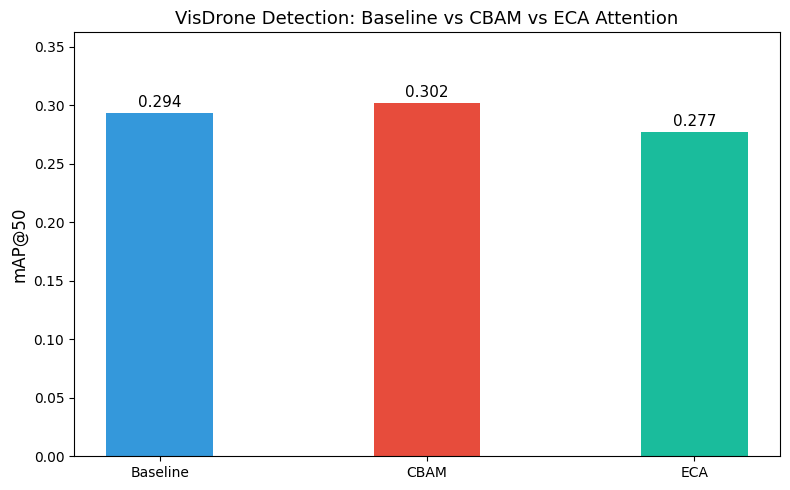

Chart saved to results/eca_vs_cbam_comparison.png


In [13]:
import matplotlib.pyplot as plt
baseline_map50 = all_metrics.get('baseline', {}).get('mAP50', 0)
cbam_map50 = all_metrics.get('cbam', {}).get('mAP50', 0)
eca_map50 = all_metrics.get('eca', {}).get('mAP50', 0)

models = ['Baseline', 'CBAM', 'ECA']
map50 = [baseline_map50, cbam_map50, eca_map50]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, map50, color=['#3498db', '#e74c3c', '#1abc9c'], width=0.4)
plt.ylabel('mAP@50', fontsize=12)
plt.title('VisDrone Detection: Baseline vs CBAM vs ECA Attention', fontsize=13)
plt.ylim(0, max(map50) * 1.2)
for bar, v in zip(bars, map50):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('results/eca_vs_cbam_comparison.png', dpi=150)
plt.show()
print('Chart saved to results/eca_vs_cbam_comparison.png')